# Prédiction de solubilité dans les solvants organiques

## Objectif
Prédire la solubilité (logS) de molécules dans 3 solvants organiques :
éthanol, benzène et acétone.

Dataset : Boobier et al. (2020), Nature Communications.
Approche : représentation molécule + solvant → logS

## Stratégie
- Représenter chaque molécule par ses descripteurs RDKit + Morgan fingerprints
- Encoder le solvant par ses paramètres physicochimiques (ε, Hansen...)
- Entraîner un modèle unique multi-solvants

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

# Chargement des données
ethanol = pd.read_csv('../data/Solubility Data/ethanol_solubility_data.csv')
benzene = pd.read_csv('../data/Solubility Data/benzene_solubility_data.csv')
acetone = pd.read_csv('../data/Solubility Data/acetone_solubility_data.csv')

print("Ethanol :", ethanol.shape)
print("Benzène :", benzene.shape)
print("Acétone :", acetone.shape)
print("\nColonnes :", ethanol.columns.tolist())
ethanol.head()

Ethanol : (695, 5)
Benzène : (464, 5)
Acétone : (452, 5)

Colonnes : ['StdInChIKey', 'SMILES', 'LogS', 'T', 'Source']


,StdInChIKey,SMILES,LogS,T,Source
0,AADVZSXPNRLYLV-XRXNUMIJSA-N,c1ccc2c(c1)c1CCN3C[C@@H]4CC[C@@H]([C@@H]([C@H]...,-2.122892,16.5,Reaxys
1,ABFDTYJJUSUWRB-UHFFFAOYSA-N,CN(C)c1ccc(cc1)N=C=Nc1ccc(cc1)N(C)C,-1.772343,21.0,Reaxys
2,ACGUYXCXAPNIKK-UHFFFAOYSA-N,C(c1c(c(cc(c1O)Cl)Cl)Cl)c1c(c(cc(c1O)Cl)Cl)Cl,0.089475,20.0,Reaxys
3,ACMLKANOGIVEPB-UHFFFAOYSA-N,c1ccc2c(c1)cc(C(=O)O)c(=O)o2,-2.823897,20.0,Reaxys
4,AECGEIVNZGQBJT-UHFFFAOYSA-N,c1ccc(cc1)C(c1ccccc1)(c1ccccc1)SCCC(=O)O,-2.110797,20.0,Reaxys


In [23]:
# Paramètres physicochimiques des solvants
solvant_params = {
    'ethanol': {'epsilon': 24.5, 'delta_D': 15.8, 'delta_P': 8.8, 'delta_H': 19.4, 'dipole': 1.69},
    'benzene': {'epsilon': 2.3,  'delta_D': 18.4, 'delta_P': 0.0, 'delta_H': 2.0,  'dipole': 0.00},
    'acetone': {'epsilon': 20.7, 'delta_D': 15.5, 'delta_P': 10.4,'delta_H': 7.0,  'dipole': 2.88},
}

# Ajouter les paramètres solvant à chaque dataset
for df_solv, nom in zip([ethanol, benzene, acetone], ['ethanol', 'benzene', 'acetone']):
    for param, val in solvant_params[nom].items():
        df_solv[param] = val
    df_solv['solvant'] = nom

# Fusionner les 3 datasets
df_all = pd.concat([ethanol, benzene, acetone], ignore_index=True)
print(f"Dataset combiné : {df_all.shape}")
df_all.head()

Dataset combiné : (1611, 11)


,StdInChIKey,SMILES,LogS,T,Source,epsilon,delta_D,delta_P,delta_H,dipole,solvant
0,AADVZSXPNRLYLV-XRXNUMIJSA-N,c1ccc2c(c1)c1CCN3C[C@@H]4CC[C@@H]([C@@H]([C@H]...,-2.122892,16.5,Reaxys,24.5,15.8,8.8,19.4,1.69,ethanol
1,ABFDTYJJUSUWRB-UHFFFAOYSA-N,CN(C)c1ccc(cc1)N=C=Nc1ccc(cc1)N(C)C,-1.772343,21.0,Reaxys,24.5,15.8,8.8,19.4,1.69,ethanol
2,ACGUYXCXAPNIKK-UHFFFAOYSA-N,C(c1c(c(cc(c1O)Cl)Cl)Cl)c1c(c(cc(c1O)Cl)Cl)Cl,0.089475,20.0,Reaxys,24.5,15.8,8.8,19.4,1.69,ethanol
3,ACMLKANOGIVEPB-UHFFFAOYSA-N,c1ccc2c(c1)cc(C(=O)O)c(=O)o2,-2.823897,20.0,Reaxys,24.5,15.8,8.8,19.4,1.69,ethanol
4,AECGEIVNZGQBJT-UHFFFAOYSA-N,c1ccc(cc1)C(c1ccccc1)(c1ccccc1)SCCC(=O)O,-2.110797,20.0,Reaxys,24.5,15.8,8.8,19.4,1.69,ethanol


In [24]:
def calculer_descripteurs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # si le SMILES est invalide
        return None
    return {
        'LogP': Descriptors.MolLogP(mol),
        'MolWt': Descriptors.MolWt(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
    }

def calculer_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

In [25]:
# Calculer descripteurs et fingerprints pour toutes les molécules
descripteurs = pd.DataFrame(df_all['SMILES'].apply(calculer_descripteurs).tolist())
fp_matrix = np.array([calculer_fingerprint(s) for s in df_all['SMILES']])

# Paramètres solvant + température
solvant_features = df_all[['epsilon', 'delta_D', 'delta_P', 'delta_H', 'dipole', 'T']].values

# Combiner tout
X = np.hstack([fp_matrix, descripteurs.values, solvant_features])
y = df_all['LogS'].values

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X shape : (1611, 2060)
y shape : (1611,)


In [26]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Évaluer
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print(f"XGBoost multi-solvants → R² : {r2:.3f} | RMSE : {rmse:.3f}")

XGBoost multi-solvants → R² : 0.430 | RMSE : 0.831


ethanol    → R² : 0.491 | RMSE : 0.797
benzene    → R² : 0.465 | RMSE : 0.805
acetone    → R² : 0.296 | RMSE : 0.892


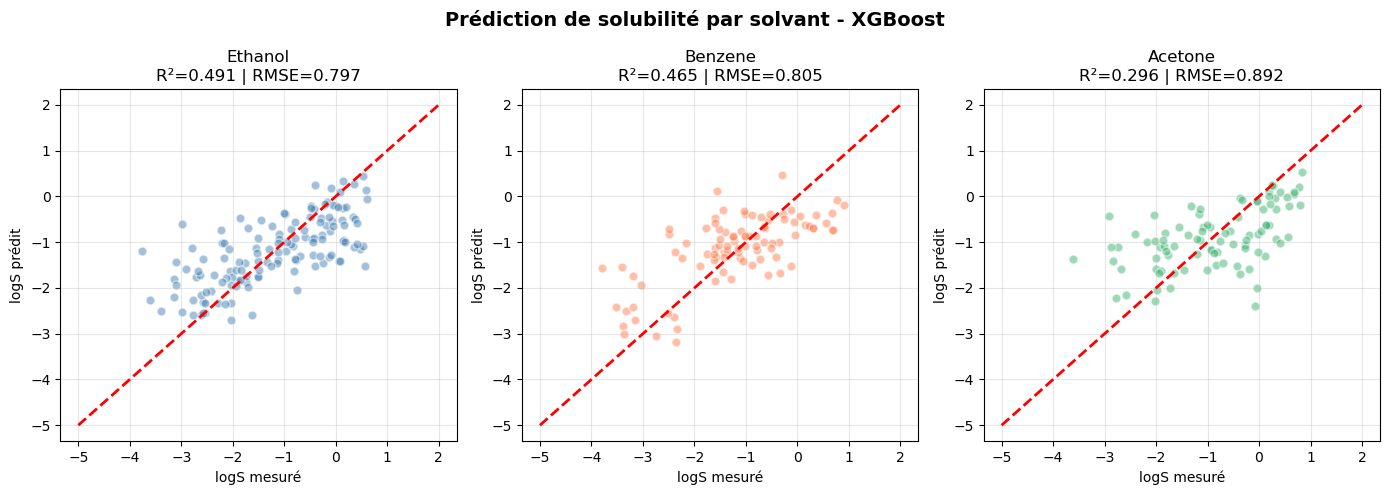

In [27]:
resultats = {}
predictions = {}  # stocke y_te et y_pr pour chaque solvant

for solvant, df_s in zip(['ethanol', 'benzene', 'acetone'], [ethanol, benzene, acetone]):
    desc_s = pd.DataFrame(df_s['SMILES'].apply(calculer_descripteurs).tolist())
    fp_s = np.array([calculer_fingerprint(s) for s in df_s['SMILES']])
    X_s = np.hstack([fp_s, desc_s.values])
    y_s = df_s['LogS'].values
    
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
    model_s = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model_s.fit(X_tr, y_tr)
    y_pr = model_s.predict(X_te)
    
    r2_s = r2_score(y_te, y_pr)
    rmse_s = np.sqrt(mean_squared_error(y_te, y_pr))
    resultats[solvant] = {'r2': r2_s, 'rmse': rmse_s}
    predictions[solvant] = {'y_te': y_te, 'y_pr': y_pr}
    print(f"{solvant:10} → R² : {r2_s:.3f} | RMSE : {rmse_s:.3f}")

# Visualisation
couleurs = {'ethanol': 'steelblue', 'benzene': 'coral', 'acetone': 'mediumseagreen'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, solvant in zip(axes, ['ethanol', 'benzene', 'acetone']):
    y_te = predictions[solvant]['y_te']
    y_pr = predictions[solvant]['y_pr']
    r2 = resultats[solvant]['r2']
    rmse = resultats[solvant]['rmse']
    
    ax.scatter(y_te, y_pr, alpha=0.5, color=couleurs[solvant], edgecolors='white', s=40)
    ax.plot([-5, 2], [-5, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS mesuré')
    ax.set_ylabel('logS prédit')
    ax.set_title(f'{solvant.capitalize()}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Prédiction de solubilité par solvant - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusions

Modèle multi-solvants XGBoost : R²=0.430, RMSE=0.831

### Performances par solvant
| Solvant | R² | RMSE |
|---|---|---|
| Éthanol | 0.491 | 0.797 |
| Benzène | 0.465 | 0.805 |
| Acétone | 0.296 | 0.892 |

### Limites
- Descripteurs 2D uniquement — pas d'énergie de solvatation ni de point de fusion
- Dataset limité (≈500 molécules par solvant)

### Perspectives
- Intégration de descripteurs DFT (énergie de solvatation, HOMO/LUMO)
- Extension à d'autres solvants
- Développement d'un outil de recommandation de solvant

In [28]:
desc_boobier = pd.read_csv('../data/Descriptors/ethanol_set_descriptors.csv')
print(desc_boobier.shape)
print(desc_boobier.columns.tolist())
desc_boobier.head()

(695, 45)
['StdInChIKey', 'SMILES', 'Train_test', 'LogS', 'MW', 'MP', 'Volume', 'E0_gas', 'E0_solv', 'DeltaE0_sol', 'G_gas', 'G_solv', 'DeltaG_sol', 'HF_E0_gas', 'HF_E0_solv', 'HF_DeltaE0_sol', 'HF_G_gas', 'HF_G_solv', 'HF_DeltaG_sol', 'gas_dip', 'solv_dip', 'HOMO', 'LUMO', 'LsoluHsolv', 'LsolvHsolu', 'SASA', 'O_charges', 'C_charges', 'Most_neg', 'Most_pos', 'Het_charges', 'N_atoms', 'Area1', 'Area2', 'Area3', 'Asp1', 'Asp2', 'Asp3', 'No_regions', 'Tot_charge', 'Neg_charge', 'Pos_charge', 'Big_area', 'Big_charge', 'Big_std']


,StdInChIKey,SMILES,Train_test,LogS,MW,MP,Volume,E0_gas,E0_solv,DeltaE0_sol,...,Asp1,Asp2,Asp3,No_regions,Tot_charge,Neg_charge,Pos_charge,Big_area,Big_charge,Big_std
0,AADVZSXPNRLYLV-XRXNUMIJSA-N,c1ccc2c(c1)c1CCN3C[C@@H]4CC[C@@H]([C@@H]([C@H]...,Train,-2.122892,340.422,282.00,272.838,-1111.820345,-1111.838822,-0.018477,...,0.389530,0.593017,0.628736,6,12.948427,-227.758251,240.706678,4780,0.032201,0.013820
1,ABFDTYJJUSUWRB-UHFFFAOYSA-N,CN(C)c1ccc(cc1)N=C=Nc1ccc(cc1)N(C)C,Train,-1.772343,280.373,88.75,277.864,-878.849800,-878.860461,-0.010661,...,0.369820,0.397934,0.961286,3,-102.208539,-262.569319,160.360780,7770,-0.033793,0.009283
2,ACGUYXCXAPNIKK-UHFFFAOYSA-N,C(c1c(c(cc(c1O)Cl)Cl)Cl)c1c(c(cc(c1O)Cl)Cl)Cl,Train,0.089475,406.907,163.75,206.079,-3410.630191,-3410.638092,-0.007901,...,0.590707,0.677793,0.891304,10,101.754750,-32.805814,134.560564,1208,0.037629,0.018139
3,ACMLKANOGIVEPB-UHFFFAOYSA-N,c1ccc2c(c1)cc(C(=O)O)c(=O)o2,Test,-2.823897,190.155,189.00,141.570,-685.616960,-685.632990,-0.016030,...,0.329787,0.492063,0.651287,4,17.568174,-212.046984,229.615158,5397,0.036717,0.010000
4,AECGEIVNZGQBJT-UHFFFAOYSA-N,c1ccc(cc1)C(c1ccccc1)(c1ccccc1)SCCC(=O)O,Train,-2.110797,348.466,204.00,266.199,-1399.063851,-1399.076930,-0.013078,...,0.630464,0.899207,0.970221,18,-63.425456,-173.402459,109.977003,1881,-0.039661,0.013220


In [29]:
descripteurs_boobier = ['MW', 'MP', 'Volume', 'G_solv', 'DeltaG_sol', 
                         'solv_dip', 'LsoluHsolv', 'LsolvHsolu', 'SASA',
                         'O_charges', 'C_charges', 'Most_neg', 'Most_pos', 'Het_charges']

# Vérifier lesquels sont présents
disponibles = [d for d in descripteurs_boobier if d in desc_boobier.columns]
manquants = [d for d in descripteurs_boobier if d not in desc_boobier.columns]

print(f"Disponibles ({len(disponibles)}) : {disponibles}")
print(f"Manquants ({len(manquants)}) : {manquants}")

Disponibles (14) : ['MW', 'MP', 'Volume', 'G_solv', 'DeltaG_sol', 'solv_dip', 'LsoluHsolv', 'LsolvHsolu', 'SASA', 'O_charges', 'C_charges', 'Most_neg', 'Most_pos', 'Het_charges']
Manquants (0) : []


ethanol    → R² : 0.547 | RMSE : 0.751
benzene    → R² : 0.620 | RMSE : 0.678
acetone    → R² : 0.476 | RMSE : 0.770


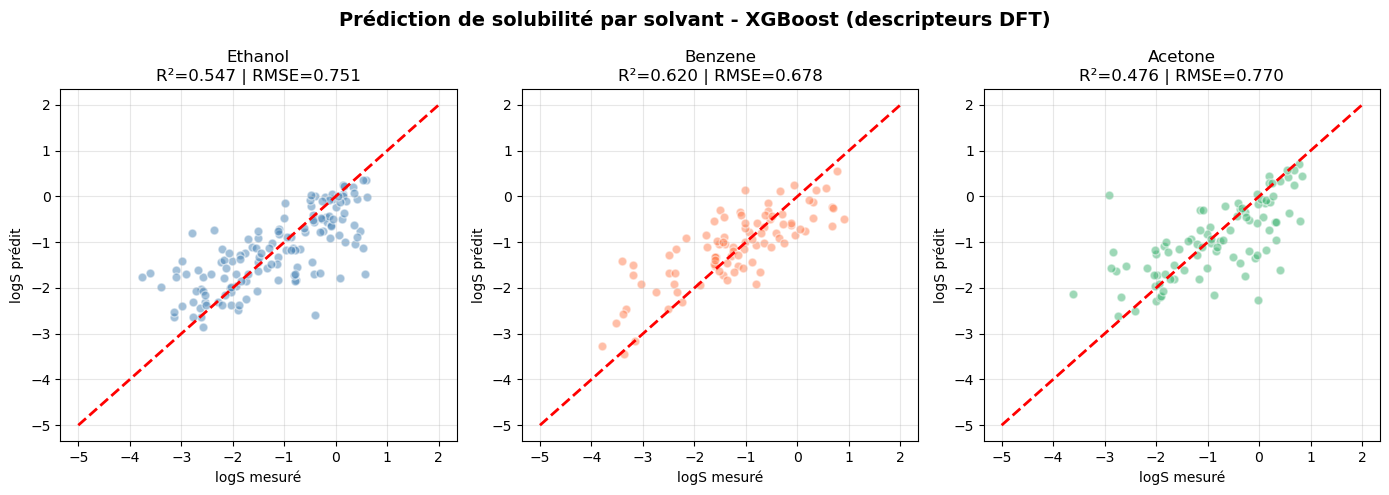

In [30]:
resultats_dft = {}
predictions_dft = {}

for solvant, df_dft in zip(['ethanol', 'benzene', 'acetone'], 
                            [ethanol_dft, benzene_dft, acetone_dft]):
    df_clean = df_dft[features_boobier + ['LogS']].dropna()
    X_dft = df_clean[features_boobier].values
    y_dft = df_clean['LogS'].values
    
    X_tr, X_te, y_tr, y_te = train_test_split(X_dft, y_dft, test_size=0.2, random_state=42)
    model_dft = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model_dft.fit(X_tr, y_tr)
    y_pr = model_dft.predict(X_te)
    
    r2_s = r2_score(y_te, y_pr)
    rmse_s = np.sqrt(mean_squared_error(y_te, y_pr))
    resultats_dft[solvant] = {'r2': r2_s, 'rmse': rmse_s}
    predictions_dft[solvant] = {'y_te': y_te, 'y_pr': y_pr}
    print(f"{solvant:10} → R² : {r2_s:.3f} | RMSE : {rmse_s:.3f}")

# Visualisation
couleurs = {'ethanol': 'steelblue', 'benzene': 'coral', 'acetone': 'mediumseagreen'}
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, solvant in zip(axes, ['ethanol', 'benzene', 'acetone']):
    y_te = predictions_dft[solvant]['y_te']
    y_pr = predictions_dft[solvant]['y_pr']
    r2 = resultats_dft[solvant]['r2']
    rmse = resultats_dft[solvant]['rmse']
    
    ax.scatter(y_te, y_pr, alpha=0.5, color=couleurs[solvant], edgecolors='white', s=40)
    ax.plot([-5, 2], [-5, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS mesuré')
    ax.set_ylabel('logS prédit')
    ax.set_title(f'{solvant.capitalize()}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Prédiction de solubilité par solvant - XGBoost (descripteurs DFT)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ethanol    → R² : 0.597 | RMSE : 0.708
benzene    → R² : 0.677 | RMSE : 0.625
acetone    → R² : 0.531 | RMSE : 0.729


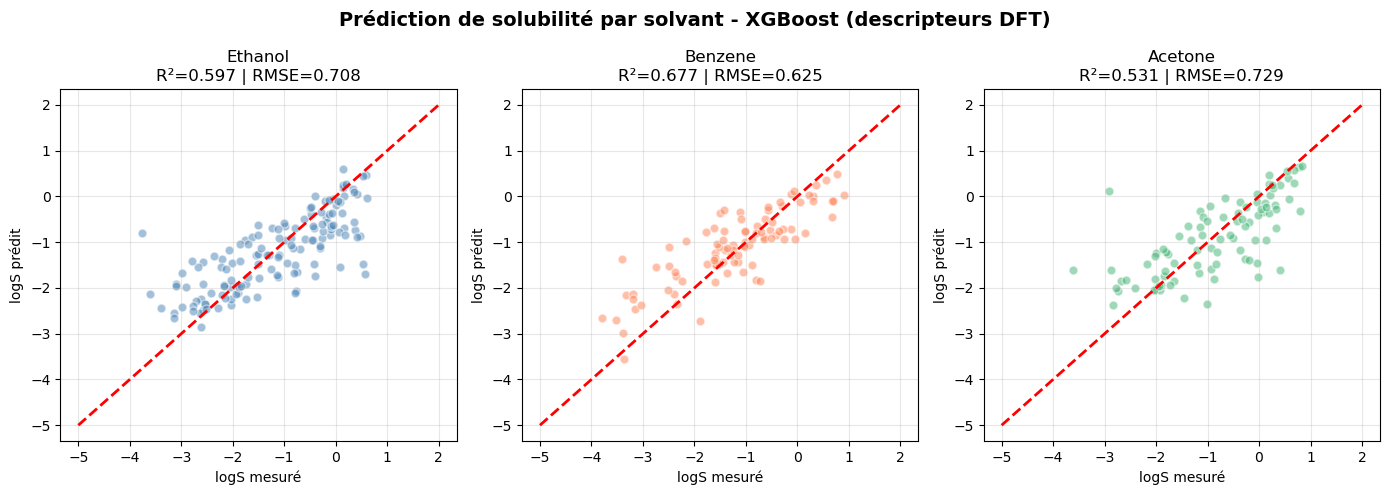

In [31]:
resultats_dft = {}
predictions_dft = {}

for solvant, df_dft in zip(['ethanol', 'benzene', 'acetone'], 
                            [ethanol_dft, benzene_dft, acetone_dft]):
    df_clean = df_dft[features_boobier + ['LogS', 'SMILES']].dropna()
    X_dft = df_clean[features_boobier].values
    fp = np.array([calculer_fingerprint(s) for s in df_clean['SMILES']])
    X_combined = np.hstack([fp, X_dft])
    y_dft = df_clean['LogS'].values

    
    X_tr, X_te, y_tr, y_te = train_test_split(X_combined, y_dft, test_size=0.2, random_state=42)
    model_dft = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model_dft.fit(X_tr, y_tr)
    y_pr = model_dft.predict(X_te)
    
    r2_s = r2_score(y_te, y_pr)
    rmse_s = np.sqrt(mean_squared_error(y_te, y_pr))
    resultats_dft[solvant] = {'r2': r2_s, 'rmse': rmse_s}
    predictions_dft[solvant] = {'y_te': y_te, 'y_pr': y_pr}
    print(f"{solvant:10} → R² : {r2_s:.3f} | RMSE : {rmse_s:.3f}")

# Visualisation
couleurs = {'ethanol': 'steelblue', 'benzene': 'coral', 'acetone': 'mediumseagreen'}
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, solvant in zip(axes, ['ethanol', 'benzene', 'acetone']):
    y_te = predictions_dft[solvant]['y_te']
    y_pr = predictions_dft[solvant]['y_pr']
    r2 = resultats_dft[solvant]['r2']
    rmse = resultats_dft[solvant]['rmse']
    
    ax.scatter(y_te, y_pr, alpha=0.5, color=couleurs[solvant], edgecolors='white', s=40)
    ax.plot([-5, 2], [-5, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS mesuré')
    ax.set_ylabel('logS prédit')
    ax.set_title(f'{solvant.capitalize()}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Prédiction de solubilité par solvant - XGBoost (descripteurs DFT)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()